In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from sktime.forecasting.naive import NaiveForecaster
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from scipy.special import inv_boxcox
from scipy.stats import boxcox
import pmdarima as pm




from sktime.performance_metrics.forecasting import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [2]:
df = pd.read_csv("internet_usage_MAR.csv")

In [4]:
display(df.head())

,Values,Timestamp
0,0.693791,2000
1,1.371440,2001
2,2.373250,2002
3,3.353370,2003
4,11.607900,2004


In [5]:
train = df["Values"][:-int(0.2*len(df))]
test = df["Values"][-int(0.2*len(df)):]
train_df = df[:-int(0.2*len(df))]
test_df = df[-int(0.2*len(df)):]
time_stamps = int(0.2*len(df))+1

In [6]:
baseline_model = NaiveForecaster(strategy="mean")
baseline_model.fit(train)
y_pred = baseline_model.predict(fh=[i for i in range(1,time_stamps)])

In [7]:
prediction = pd.DataFrame({"Values":y_pred})
prediction["Timestamp"] = test_df["Timestamp"]

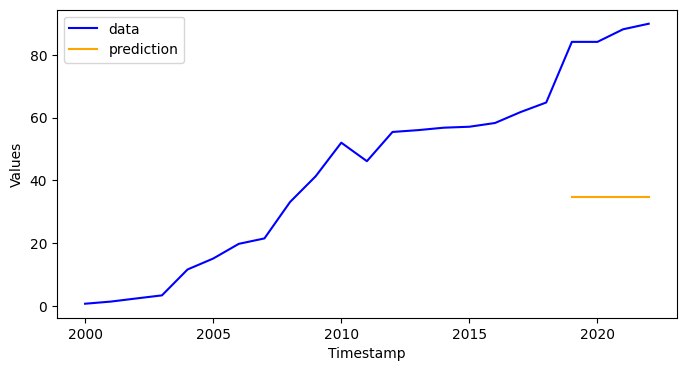

In [8]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="Timestamp",y="Values",color="blue",label="data")
sns.lineplot(data=prediction,x="Timestamp",y="Values",color="orange",label="prediction")
plt.show()

In [9]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 51.91667757894737
RMSE: 51.978096684933085
MAPE: 0.5993834898275527


# Using a more sophisticated model (ARIMA) and computing the performence metrics

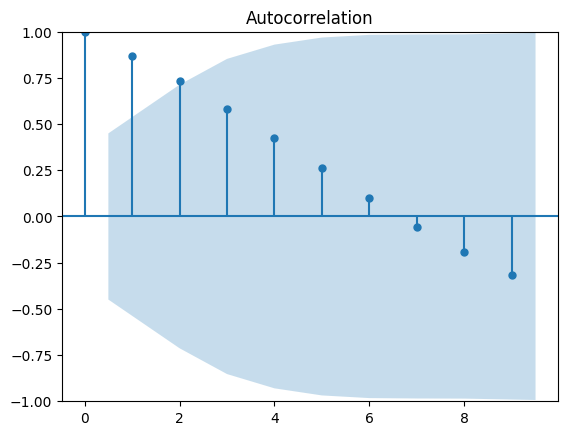

In [22]:
plot_acf(train)
plt.show()

In [11]:
model_arima = ARIMA(train,order=(23,0,23))
model_arima = model_arima.fit()
y_pred = model_arima.forecast(len(test))

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [13]:
prediction = pd.DataFrame({"Values":y_pred})
prediction["Timestamp"] = test_df["Timestamp"]

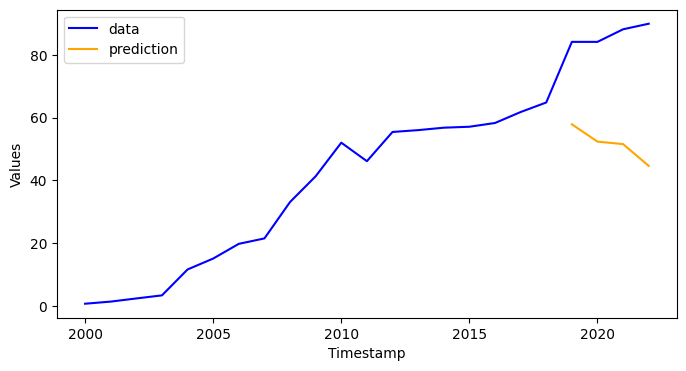

In [14]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="Timestamp",y="Values",color="blue",label="data")
sns.lineplot(data=prediction,x="Timestamp",y="Values",color="orange",label="prediction")
plt.show()

In [15]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 34.981958440521154
RMSE: 35.6722078708528
MAPE: 0.4022550321632172


# Testing a different refinement method each time and looking at the performence

* The Box Cox

In [29]:
train_BoxCox, lam = boxcox(train)
model_arima = ARIMA(train_BoxCox,order=(20,0,20))
model_arima = model_arima.fit()
y_pred = model_arima.forecast(len(test))
y_pred = inv_boxcox(y_pred,lam)

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [31]:
prediction = pd.DataFrame({"Values":y_pred})
prediction.index = range(19,19+len(prediction))
prediction["Timestamp"] = test_df["Timestamp"]

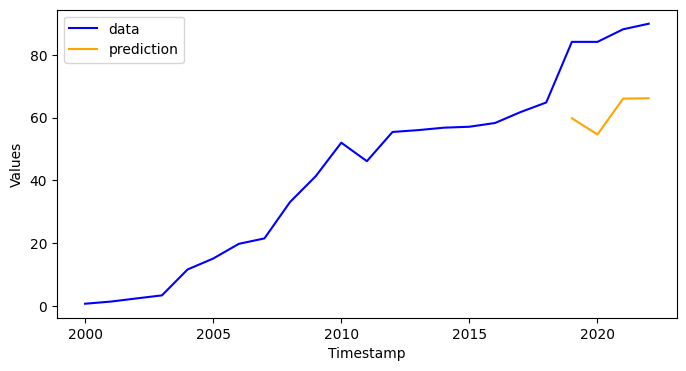

In [32]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="Timestamp",y="Values",color="blue",label="data")
sns.lineplot(data=prediction,x="Timestamp",y="Values",color="orange",label="prediction")
plt.show()

In [33]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 24.92421703185975
RMSE: 25.077778157132418
MAPE: 0.2887662037945812


* IQR impuration with the median

In [35]:
median = np.median(train)
train_IQR = train.copy()
for i in range(len(train_IQR)):
    if train_IQR[i]>1.5*median:
        train_IQR[i] = median
        

In [36]:
model_arima = ARIMA(train_IQR,order=(20,0,20))
model_arima = model_arima.fit()
y_pred = model_arima.forecast(len(test))

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [38]:
prediction = pd.DataFrame({"Values":y_pred})
prediction["Timestamp"] = test_df["Timestamp"]

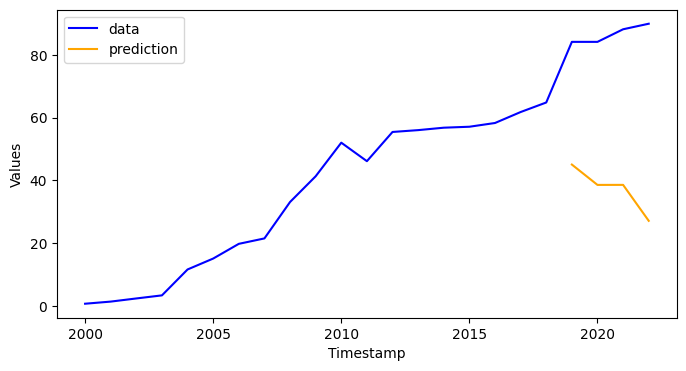

In [39]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="Timestamp",y="Values",color="blue",label="data")
sns.lineplot(data=prediction,x="Timestamp",y="Values",color="orange",label="prediction")
plt.show()

In [40]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 49.2575789050367
RMSE: 50.01361271861353
MAPE: 0.5668598383993148


* Fourier Trend

In [41]:
df_fourier = df.copy()

In [56]:
t = np.arange(len(df_fourier))
for period in range(1,20):
    for order in range(1,10):
        df_fourier[f"fourier_sin_order_{order}"] = np.sin(2* np.pi * order * t*period)
        df_fourier[f"fourier_cos_order_{order}"] = np.cos(2* np.pi * order * t*period)
    
fourier_features = [i for i in list(df_fourier) if i.startswith("fourier")]
train_df_fourier = df_fourier[:-int(0.2*len(df))]
test_df_fourier = df_fourier[-int(0.2*len(df)):]

In [57]:
model = pm.auto_arima(
    train_df_fourier["Values"],
    X = train_df_fourier[fourier_features],
    seasonal = False,
    stepwise = True,
    suppress_warnings = True,
    max_order = None,
    information_criterion = "aicc",
    error_action = "ignore"
)
y_pred = model.predict(n_periods = len(test_df_fourier), X=test_df_fourier[fourier_features])

In [58]:
prediction = pd.DataFrame({"Values":y_pred})
prediction["Timestamp"] = test_df["Timestamp"]

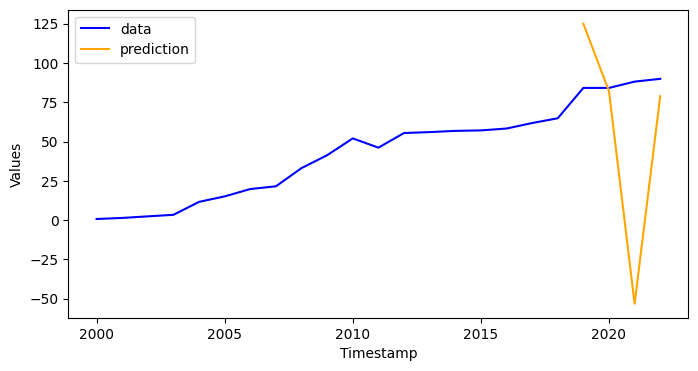

In [59]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df_fourier,x="Timestamp",y="Values",color="blue",label="data")
sns.lineplot(data=prediction,x="Timestamp",y="Values",color="orange",label="prediction")
plt.show()

In [60]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 48.8330795413971
RMSE: 73.78721065632762
MAPE: 0.5592870748582566


* Seasonal Differencing

In [17]:
df_diff = df.copy()
df_diff["Values"] = df["Values"].diff()
df_diff["Timestamp"] = df["Timestamp"]

train_diff = df["Values"][:-int(0.2*len(df))]
test_diff = df["Values"][-int(0.2*len(df)):]

train_diff.dropna(inplace=True)
base = df.iloc[int(-len(df)*0.2)-1].loc["Values"]

In [12]:
train_diff = df_diff["Values"]

In [13]:
model_arima = ARIMA(train_diff,order=(20,0,20))
model_arima = model_arima.fit()
y_pred_diff = model_arima.forecast(len(test))

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [14]:
y_pred_diff = list(y_pred_diff)

In [15]:
y_pred = []
for i in range(len(test)):
    if i<1:
        value = df.iloc[int(-len(df)*0.2)-1+i].loc["Values"]
        y_pred.append(y_pred_diff[i]+value)
    else:
        y_pred.append(y_pred_diff[i]+y_pred[-1])

In [16]:
prediction = pd.DataFrame({"Values":y_pred})
prediction.index = range(19,19+len(test))
prediction["Timestamp"] = test_df["Timestamp"]


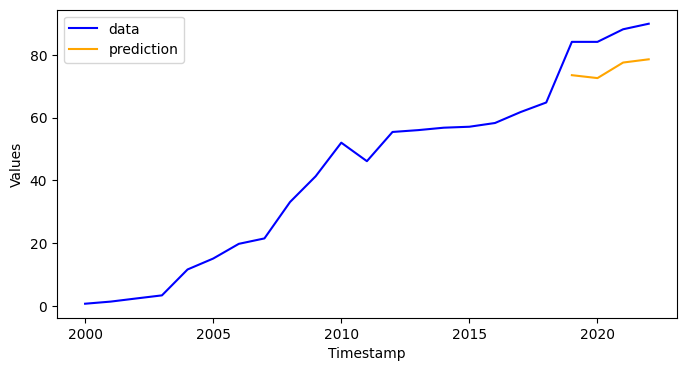

In [18]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="Timestamp",y="Values",color="blue",label="data")
sns.lineplot(data=prediction,x="Timestamp",y="Values",color="orange",label="prediction")
plt.show()

In [19]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 11.022906037889996
RMSE: 11.031017725693616
MAPE: 0.12743808355026726


In [18]:
df_diff.describe()

,Values,Timestamp
count,22.000000,23.00000
mean,4.054828,2011.00000
std,5.344235,6.78233
min,-5.892500,2000.00000
25%,0.825980,2005.50000
50%,2.405700,2011.00000
75%,7.321700,2016.50000
max,19.316500,2022.00000
